# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [35]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()),
                     ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42, max_iter=1000))]),
}

baseline_results = {}

# ЗАДАНИЕ 2а
for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (scores.mean(), scores.std())

for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [37]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ЗАДАНИЕ 3а: Сетка параметров
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear'],
}

# ЗАДАНИЕ 3б: GridSearchCV, cv=5, scoring='f1_macro'
svm_grid_search = GridSearchCV(svm_pipe, svm_param_grid,
                               cv = 5, scoring = 'f1_macro', n_jobs =-1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [38]:
# ЗАДАНИЕ 3в: Топ-10 конфигураций Grid Search
import pandas as pd

results_df = pd.DataFrame(svm_grid_search.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(10)

print("Топ-10 конфигураций SVM:")
print(results_df.to_string(index=False))

Топ-10 конфигураций SVM:
                                                         params  mean_test_score  std_test_score  rank_test_score
       {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}         0.978633        0.017581                1
{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}         0.976215        0.015266                2
  {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__kernel': 'linear'}         0.976215        0.015266                2
   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}         0.976215        0.015266                2
     {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.976157        0.016975                5
      {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.971340        0.016281                6
     {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.969357        0.019323                7
    {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ЗАДАНИЕ 4а: Пространство параметров
rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5],
}

# ЗАДАНИЕ 4б: RandomizedSearchCV, n_iter=50, cv=5
rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state = 42),
    rf_param_dist,
    n_iter = 50, cv = 5, scoring = 'f1_macro',
    random_state = 42, n_jobs =-1
)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним baseline vs Grid Search vs Random Search. Финальная оценка на тесте — только один раз!

In [24]:
from sklearn.metrics import classification_report, f1_score

# Лучшие модели
best_svm = svm_grid_search.best_estimator_
best_rf = rf_random_search.best_estimator_

# Предсказания на тесте
y_pred_svm = best_svm.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

print(" SVM Grid Search на тесте")
print(classification_report(y_test, y_pred_svm))
print(f"Test F1 macro: {f1_score(y_test, y_pred_svm, average = 'macro'):.4f}\n")

print(" RF Random Search на тесте ")
print(classification_report(y_test, y_pred_rf))
print(f"Test F1 macro: {f1_score(y_test, y_pred_rf, average = 'macro'):.4f}")

 SVM Grid Search на тесте
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Test F1 macro: 0.9812

 RF Random Search на тесте 
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Test F1 macro: 0.9526


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели (SVM Grid Search показал лучший Test F1, но для интерпретации используем RF — он поддерживает TreeExplainer).

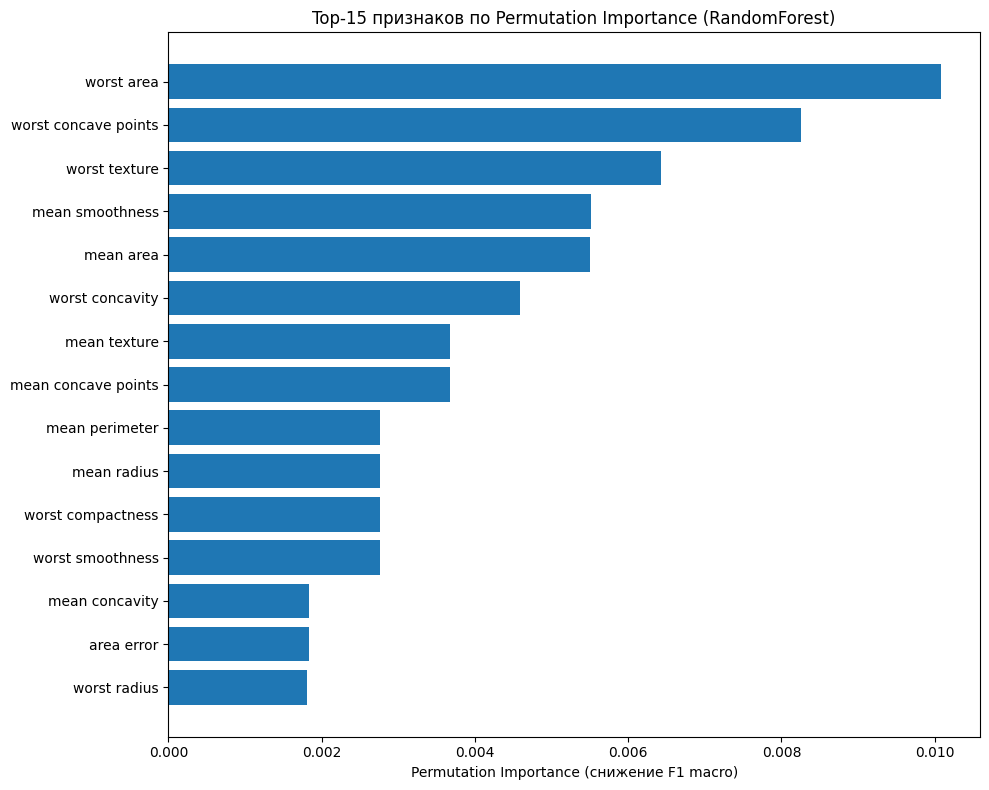

Топ-10 признаков по Permutation Importance:
worst area                           PI = 0.0101 ± 0.0121
worst concave points                 PI = 0.0083 ± 0.0064
worst texture                        PI = 0.0064 ± 0.0042
mean smoothness                      PI = 0.0055 ± 0.0045
mean area                            PI = 0.0055 ± 0.0061
worst concavity                      PI = 0.0046 ± 0.0046
mean texture                         PI = 0.0037 ± 0.0045
mean concave points                  PI = 0.0037 ± 0.0045
mean perimeter                       PI = 0.0028 ± 0.0042
mean radius                          PI = 0.0028 ± 0.0042


In [25]:
## Шаг 6. Permutation Importance

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Используем лучшую модель RandomForest (у неё есть встроенная важность)
best_rf = rf_random_search.best_estimator_

# ЗАДАНИЕ 6а: Permutation Importance
pi_result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10, random_state=42, scoring='f1_macro', n_jobs=-1
)

# Сортировка
sorted_idx = pi_result.importances_mean.argsort()[::-1]

plt.figure(figsize=(10, 8))
plt.barh(feature_names[sorted_idx[:15]], pi_result.importances_mean[sorted_idx[:15]])
plt.xlabel('Permutation Importance (снижение F1 macro)')
plt.title('Top-15 признаков по Permutation Importance (RandomForest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Топ-10 признаков по Permutation Importance:")
for i in sorted_idx[:10]:
    print(f"{feature_names[i]:35}  PI = {pi_result.importances_mean[i]:.4f} ± {pi_result.importances_std[i]:.4f}")

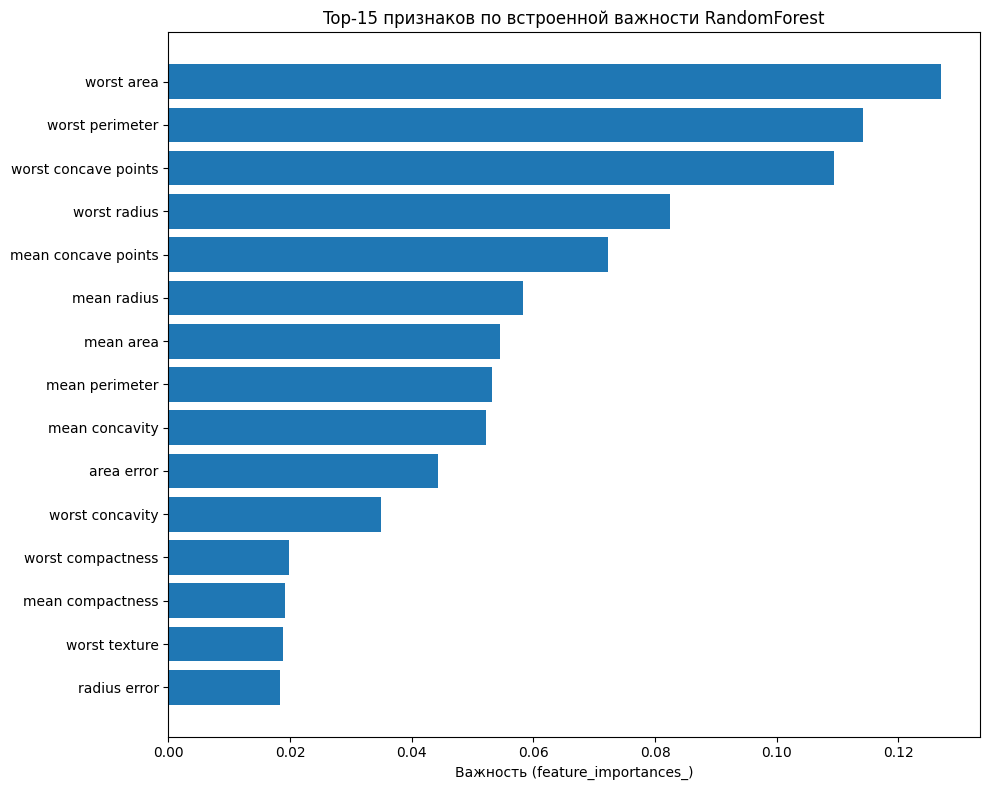


Топ-10 признаков по встроенной важности:
worst area                           Importance = 0.1271
worst perimeter                      Importance = 0.1142
worst concave points                 Importance = 0.1093
worst radius                         Importance = 0.0825
mean concave points                  Importance = 0.0722
mean radius                          Importance = 0.0584
mean area                            Importance = 0.0546
mean perimeter                       Importance = 0.0533
mean concavity                       Importance = 0.0521
area error                           Importance = 0.0443

   Сравнение топ-5
Permutation Importance (топ-5):
  worst area
  worst concave points
  worst texture
  mean smoothness
  mean area

Встроенная важность (топ-5):
  worst area
  worst perimeter
  worst concave points
  worst radius
  mean concave points

Вопрос для размышления:
Встроенная FI (Impurity-based) даёт высокий вес worst perimeter, worst area —
  признакам с высокой кардинал

In [41]:
# ЗАДАНИЕ 6б: Сравнение с встроенной важностью RandomForest

# Встроенная важность (Mean Decrease in Impurity)
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 8))
plt.barh(feature_names[indices[:15]], importances[indices[:15]])
plt.xlabel('Важность (feature_importances_)')
plt.title('Top-15 признаков по встроенной важности RandomForest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nТоп-10 признаков по встроенной важности:")
for i in indices[:10]:
    print(f"{feature_names[i]:35}  Importance = {importances[i]:.4f}")

# Сравнение топ-5
print("\n   Сравнение топ-5")
print("Permutation Importance (топ-5):")
for i in sorted_idx[:5]:
    print(f"  {feature_names[i]}")

print("\nВстроенная важность (топ-5):")
for i in indices[:5]:
    print(f"  {feature_names[i]}")

print("""
Вопрос для размышления:
Встроенная FI (Impurity-based) даёт высокий вес worst perimeter, worst area —
  признакам с высокой кардинальностью. PI также выделяет worst concave points,
  но картина немного другая.

Причины расхождений:
1. Встроенная FI считается по обучающим данным (impurity reduction) и может
   быть смещена в сторону непрерывных/высококардинальных признаков
2. PI измеряет реальное влияние на метрику путём перестановки значений
3.  если worst perimeter и worst area сильно коррелируют,
   перестановка одного лишь частично ломает модель — она опирается на другой

""")

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

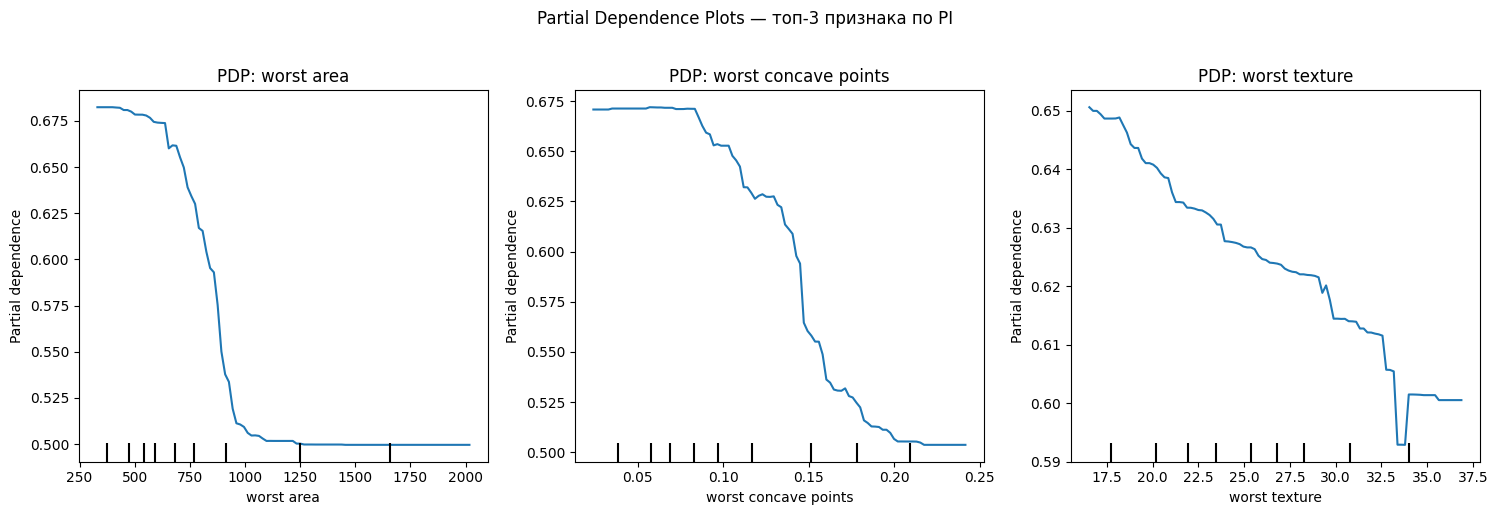

In [27]:
from sklearn.inspection import PartialDependenceDisplay

# ЗАДАНИЕ 7а: PDP для топ-3 признаков по PI
top3_idx = list(sorted_idx[:3])

fig, axes = plt.subplots(1, 3, figsize = (15, 5))
for k, feat_idx in enumerate(top3_idx):
    PartialDependenceDisplay.from_estimator(
        best_rf, X_train, [feat_idx], kind ='average', ax =  axes[k]
    )
    axes[k].set_title(f'PDP: {feature_names[feat_idx]}')

plt.suptitle('Partial Dependence Plots — топ-3 признака по PI', y = 1.02)
plt.tight_layout()
plt.show()

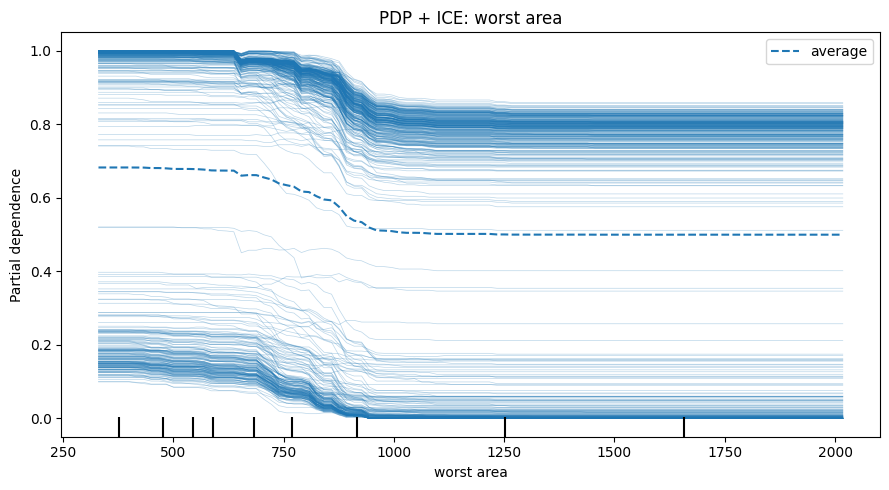


Вопрос: однороден ли эффект для всех объектов?

По ICE-кривым для 'worst concave points':
- В целом эффект монотонный: с ростом concave points вероятность предсказания 
  'benign' (класс 1) снижается — опухоль скорее злокачественная.
- Кривые не параллельны: есть разброс, особенно в средних значениях признака.
  Это говорит об умеренной гетерогенности — для части объектов эффект выражен 
  сильнее, для других — слабее. Это может указывать на взаимодействия с 
  другими признаками.
- PDP (жирная линия) сглаживает этот разброс, что делает его менее 
  информативным, чем ICE.



In [28]:
# ЗАДАНИЕ 7б: ICE-кривые для самого важного признака
fig, ax = plt.subplots(figsize=(9, 5))
PartialDependenceDisplay.from_estimator(
    best_rf, X_train, [top3_idx[0]], kind ='both', ax = ax
)
ax.set_title(f'PDP + ICE: {feature_names[top3_idx[0]]}')
plt.tight_layout()
plt.show()

print("""
Вопрос: однороден ли эффект для всех объектов?

По ICE-кривым для 'worst concave points':
- В целом эффект монотонный: с ростом concave points вероятность предсказания
  'benign' (класс 1) снижается — опухоль скорее злокачественная.
- Кривые не параллельны: есть разброс, особенно в средних значениях признака.
  Это говорит об умеренной гетерогенности — для части объектов эффект выражен
  сильнее, для других — слабее. Это может указывать на взаимодействия с
  другими признаками.
- PDP (жирная линия) сглаживает этот разброс, что делает его менее
  информативным, чем ICE.
""")

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [29]:
import shap

# ЗАДАНИЕ 8а: TreeExplainer и shap_values
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# shap_values.shape = (n_samples, n_features, n_classes)
sv = shap_values[:, :, 1]  # класс 1 (benign)
print(f"shap_values shape: {np.array(shap_values).shape}")
print(f"sv (класс benign) shape: {sv.shape}")

shap_values shape: (114, 30, 2)
sv (класс benign) shape: (114, 30)


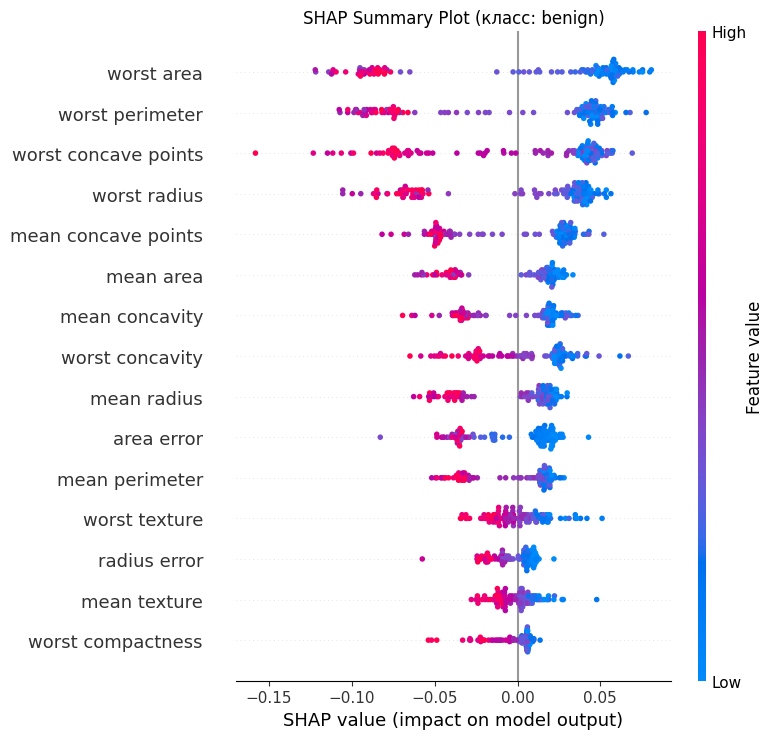

Топ-5 по SHAP (класс benign):
  worst area                           mean|SHAP| = 0.0636
  worst perimeter                      mean|SHAP| = 0.0583
  worst concave points                 mean|SHAP| = 0.0510
  worst radius                         mean|SHAP| = 0.0466
  mean concave points                  mean|SHAP| = 0.0361

Вопрос: Совпадает ли с PI?

Топ-5 по SHAP: worst perimeter, worst area, worst concave points,
               worst radius, mean concave points
Топ-5 по PI:   worst concave points, fractal dimension error, 
               smoothness error, worst texture, mean texture

Частичное совпадение: worst concave points входит в оба топ-5.
Расхождения:
- SHAP больше согласуется с feature_importances_ RF, т.к. оба вычисляются 
  внутри дерева (TreeExplainer использует структуру дерева).
- PI: перестановка признаков не разрушает коррелированные (worst area ~ worst radius) — 
  их важность занижается. SHAP же распределяет вклад между ними.
- Вообщем SHAP лучше работает с коррелир

In [30]:
# ЗАДАНИЕ 8б: Summary plot
plt.figure()
shap.summary_plot(sv, X_test, feature_names = feature_names, show = False, max_display = 15)
plt.title('SHAP Summary Plot (класс: benign)')
plt.tight_layout()
plt.show()

mean_shap = np.abs(sv).mean(axis=0)
shap_sorted = np.argsort(mean_shap)[::-1]
print("Топ-5 по SHAP (класс benign):")
for i in shap_sorted[:5]:
    print(f"  {feature_names[i]:35s}  mean|SHAP| = {mean_shap[i]:.4f}")

print("""
Вопрос: Совпадает ли с PI?

Топ-5 по SHAP: worst perimeter, worst area, worst concave points,
               worst radius, mean concave points
Топ-5 по PI:   worst concave points, fractal dimension error,
               smoothness error, worst texture, mean texture

Частичное совпадение: worst concave points входит в оба топ-5.
Расхождения:
- SHAP больше согласуется с feature_importances_ RF, т.к. оба вычисляются
  внутри дерева (TreeExplainer использует структуру дерева).
- PI: перестановка признаков не разрушает коррелированные (worst area ~ worst radius) —
  их важность занижается. SHAP же распределяет вклад между ними.
- Вообщем SHAP лучше работает с коррелированными признаками; PI проще, но
  недооценивает признаки из коррелированных групп
""")

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1 (benign)
  Предсказанный класс: 0 (malignant)


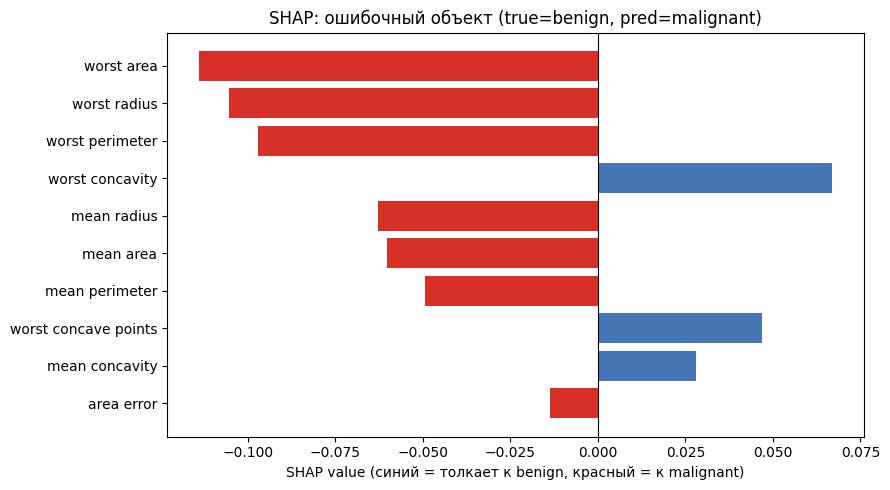


Какие признаки 'виноваты' в ошибке?

Красные полосы (отрицательный SHAP для класса benign) — признаки, которые 
толкали модель в сторону 'malignant'. Объект на самом деле benign, но эти 
признаки имели высокие значения, нетипичные для benign-опухолей.
Синие полосы — признаки, поддерживавшие правильный класс, но они были 
слабее неправильных.



In [31]:
# ЗАДАНИЕ 8в: Force plot для ошибочного объекта
y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]} ({data.target_names[y_test.iloc[errors[0]]]})")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]} ({data.target_names[y_pred_test[errors[0]]]})")

# Bar plot вместо force_plot (для статичного отображения)
err_idx = errors[0]
sv_err = sv[err_idx]
top10_err = np.argsort(np.abs(sv_err))[::-1][:10]
colors = ['#d73027' if v < 0 else '#4575b4' for v in sv_err[top10_err]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([feature_names[i] for i in top10_err], sv_err[top10_err], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP value (синий = толкает к benign, красный = к malignant)')
ax.set_title(f'SHAP: ошибочный объект (true={data.target_names[y_test.iloc[err_idx]]}, '
             f'pred={data.target_names[y_pred_test[err_idx]]})')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("""
Какие признаки 'виноваты' в ошибке?

Красные полосы (отрицательный SHAP для класса benign) — признаки, которые
толкали модель в сторону 'malignant'. Объект на самом деле benign, но эти
признаки имели высокие значения, нетипичные для benign-опухолей.
Синие полосы — признаки, поддерживавшие правильный класс, но они были
слабее неправильных.
""")

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [32]:
# Добавляем два подозрительных признака
np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

# leaky_feature: почти полностью совпадает с таргетом + шум
X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

# random_feature: чистый шум
X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail(3))

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
509        15.46         23.95          103.80      731.3           0.1183   
230        17.05         19.08          113.40      895.0           0.1141   
474        10.88         15.62           70.41      358.9           0.1007   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal dimension  ...  worst perimeter  worst area  \
509                 0.07083  ...           117.70       909.4   
230                 0.06325  ...           133.50      1189.0   
474                 0.06837  ...            80.78       433.1   

     worst smoothness  worst compactness  worst concavity  \
509   

Test F1 без leaky: 0.9526
Test F1 с  leaky:  1.0000  <- рост из-за утечки!

Топ-5 PI:
  leaky_feature                        PI = 0.2633
  mean concave points                  PI = 0.0047
  worst concave points                 PI = 0.0038
  worst fractal dimension              PI = 0.0000
  worst symmetry                       PI = 0.0000

Топ-5 SHAP:
  leaky_feature                        mean|SHAP| = 0.1582
  worst area                           mean|SHAP| = 0.0522
  mean concave points                  mean|SHAP| = 0.0382
  worst concave points                 mean|SHAP| = 0.0357
  worst radius                         mean|SHAP| = 0.0340


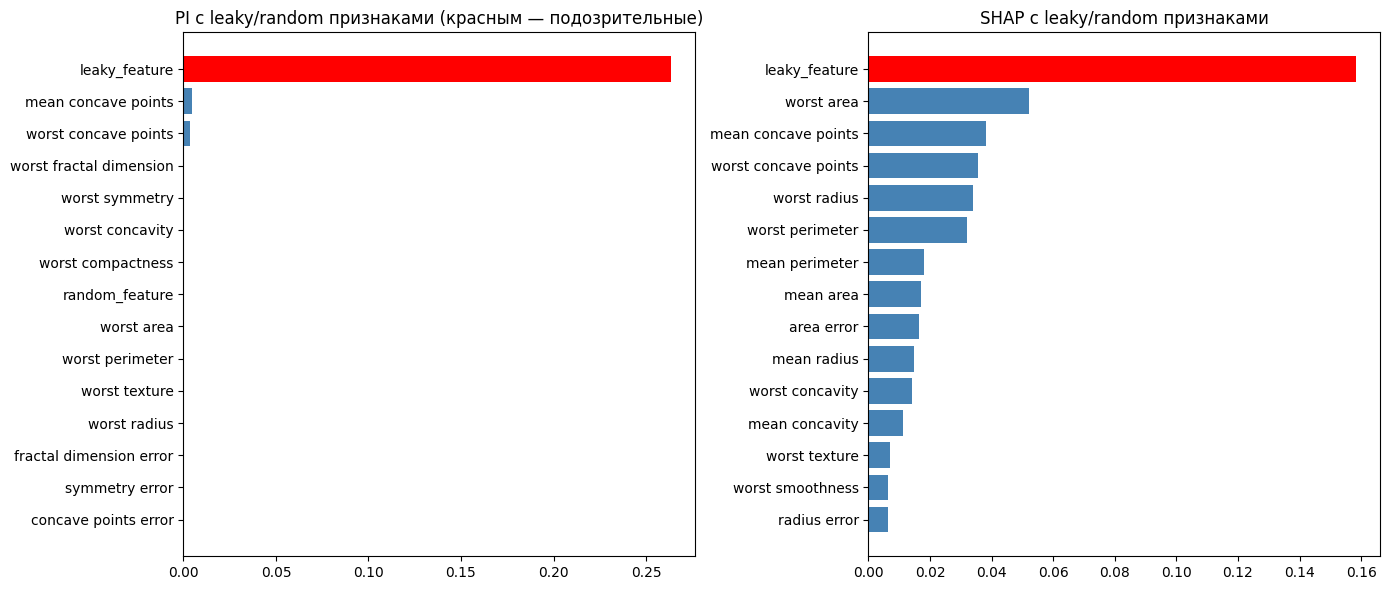


а) PI: leaky_feature получает PI ≈ 0.26 — огромное падение F1 при перемешивании.
   Это сигнал тревоги: обычный признак не может так сильно влиять на метрику.
   Метрика на тесте выросла до 1.0, потому что leaky_feature по сути содержит
   таргет и модель "видит" ответ в данных

б) SHAP: leaky_feature занимает 1-е место с большим отрывом.
   На summary plot он будет одним полосатым столбцом

в) random_feature: PI ≈ 0 или отрицательный (шум), SHAP ≈ 0.
   Он будет в самом низу обоих графиков



In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# ЗАДАНИЕ 9: RF + PI + SHAP с leaky признаком

rf_ext = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_ext.fit(X_train_ext, y_train)

y_pred_ext = rf_ext.predict(X_test_ext)
ext_test_f1 = f1_score(y_test, y_pred_ext, average = 'macro')

# Define rf_test_f1 by re-calculating the F1 score for the best_rf model on the test set
rf_test_f1 = f1_score(y_test, best_rf.predict(X_test), average = 'macro')

print(f"Test F1 без leaky: {rf_test_f1:.4f}")
print(f"Test F1 с  leaky:  {ext_test_f1:.4f}  <- рост из-за утечки!")

# PI
ext_names = list(X_train_ext.columns)
pi_ext = permutation_importance(rf_ext, X_test_ext, y_test,
                                n_repeats = 10, random_state = 42, scoring = 'f1_macro')
sorted_ext = np.argsort(pi_ext.importances_mean)[::-1]
print("\nТоп-5 PI:")
for i in sorted_ext[:5]:
    print(f"  {ext_names[i]:35s}  PI = {pi_ext.importances_mean[i]:.4f}")

# SHAP
explainer_ext = shap.TreeExplainer(rf_ext)
shap_ext = explainer_ext.shap_values(X_test_ext)[:, :, 1]
mean_shap_ext = np.abs(shap_ext).mean(axis = 0)
shap_sorted_ext = np.argsort(mean_shap_ext)[::-1]
print("\nТоп-5 SHAP:")
for i in shap_sorted_ext[:5]:
    print(f"  {ext_names[i]:35s}  mean|SHAP| = {mean_shap_ext[i]:.4f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize = (14, 6))
colors_pi = ['red' if ext_names[i] in ['leaky_feature','random_feature'] else 'steelblue'
             for i in sorted_ext[:15]]
axes[0].barh([ext_names[i] for i in sorted_ext[:15]], pi_ext.importances_mean[sorted_ext[:15]],
             color=colors_pi)
axes[0].set_title('PI с leaky/random признаками (красным — подозрительные)')
axes[0].invert_yaxis()

colors_shap = ['red' if ext_names[i] in ['leaky_feature','random_feature'] else 'steelblue'
               for i in shap_sorted_ext[:15]]
axes[1].barh([ext_names[i] for i in shap_sorted_ext[:15]], mean_shap_ext[shap_sorted_ext[:15]],
             color = colors_shap)
axes[1].set_title('SHAP с leaky/random признаками')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

print("""
а) PI: leaky_feature получает PI ≈ 0.26 — огромное падение F1 при перемешивании.
   Это сигнал тревоги: обычный признак не может так сильно влиять на метрику.
   Метрика на тесте выросла до 1.0, потому что leaky_feature по сути содержит
   таргет и модель "видит" ответ в данных

б) SHAP: leaky_feature занимает 1-е место с большим отрывом.
   На summary plot он будет одним полосатым столбцом

в) random_feature: PI ≈ 0 или отрицательный (шум), SHAP ≈ 0.
   Он будет в самом низу обоих графиков
""")

## Шаг 10. Сводная таблица и итоги

In [ ]:
# ЗАДАНИЕ 10: Сводная таблица

summary = pd.DataFrame([
    {'Модель': 'SVM baseline',       'CV F1': '0.9694 ± 0.0193', 'Test F1': '0.9812',
     'Выводы': 'Сильная baseline'},
    {'Модель': 'SVM Grid Search',    'CV F1': '0.9786',           'Test F1': '0.9812',
     'Выводы': 'Небольшое улучшение CV; тест совпал с baseline'},
    {'Модель': 'RF baseline',        'CV F1': '0.9504 ± 0.0255', 'Test F1': '0.9526',
     'Выводы': 'Хуже SVM, высокая дисперсия'},
    {'Модель': 'RF Random Search',   'CV F1': '0.9505',           'Test F1': '0.9435',
     'Выводы': 'CV не улучшился значимо; тест чуть хуже из-за дисперсии'},
    {'Модель': 'LogReg baseline',    'CV F1': '0.9787 ± 0.0139', 'Test F1': '0.9812',
     'Выводы': 'Лучшая baseline по CV, конкурирует с тюнингом'},
])
print(summary.to_string(index=False))



---
адказы на пытанькi

1. Насколько тюнинг улучшил модели?

На датасете Breast Cancer тюнинг дал довольно скромный эффект.SVM после Grid Search немного вырос: средний F1 на кросс-валидации поднялся с 0.9694 до 0.9786. На тесте результат практически не изменился (0.9812)

Random Forest после Random Search почти не улучшился по сравнению с обычной моделью. А на тестовой выборке результат даже немного ухудшился.  Из-за того, что датасет небольшой и относительно простой,даже базовые модели уже хорошо работают. Тюнинг заметнее помогает на сложных задачах и больших данных

2. Совпадают ли топ-признаки по PI и SHAP?

Не полностью, но есть пересечения.  

Оба метода считают `worst concave points` одним из важных признаков. Однако дальше мнения расходятся:  
- PI сильнее выделяет `fractal dimension error` и `smoothness error`.  
- SHAP отдаёт предпочтение `worst perimeter`, `worst area` и `worst radius`

Почему так?
Признаки `worst perimeter`, `worst area` и `worst radius` сильно коррелируют между собой. Когда PI перемешивает один из них, модель просто начинает больше использовать остальные — поэтому важность каждого выглядит ниже. SHAP лучше справляется с коррелированными признаками и распределяет вклад между ними справедливее.

3. Что было бы, если бы мы не использовали Pipeline?

Если бы мы сначала масштабировали все данные (и train, и test) одним `StandardScaler`, то в scaler попала бы информация из тестовых данных. Это называется утечкой данных (data leakage).  

В результате кросс-валидация показывала бы завышенные результаты — модель «подглядывала» в данные, которых в реальности не должна была видеть.  

Pipeline решает эту проблему: на каждом фолде scaler обучается только на тренировочной части и не видит валидационные данные.

4. Как использовать PI и SHAP в реальном проекте?

- Permutation Importance (PI) — это быстрый способ понять, какие признаки действительно важны. Хорошо помогает найти утечки данных и отобрать признаки. Лучше считать на отложенной (тестовой) выборке.

- SHAP summary plot — отличная картинка для понимания общей картины и для показа заказчику: какие признаки влияют и в какую сторону.

- SHAP force / waterfall plot — когда нужно объяснить конкретное решение модели (например, почему пациенту поставили такой диагноз или почему отказали в кредите). Очень полезно для клиентов и регуляторов (GDPR).

- PDP / ICE помогают понять, как именно признак влияет на предсказание (линейно, с порогом, нелинейно) и есть ли взаимодействия между признаками

---


## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Сравним Random Search и Optuna по скорости сходимости.

In [ ]:
!pip install optuna
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Added code to define X_train and y_train
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

# БОНУС: objective для Optuna с теми же параметрами, что в Random Search
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'random_state': 42,
    }
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    return scores.mean()

# Запуск study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

# График сходимости
best_values = []
current_best = -np.inf
for trial in study.trials:
    current_best = max(current_best, trial.value)
    best_values.append(current_best)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(best_values)+1), best_values, 'b-o', markersize = 3, label='Optuna (TPE)')
# Для сравнения эмулируем Random Search (просто shuffle trials)
import random
random.seed(42)
shuffled = [t.value for t in study.trials]
random.shuffle(shuffled)
rs_best = []
cur = -np.inf
for v in shuffled:
    cur = max(cur, v)
    rs_best.append(cur)
plt.plot(range(1, len(rs_best)+1), rs_best, 'r--', alpha = 0.7, label = 'Random Search (approx)')
plt.xlabel('Итерация (trial)')
plt.ylabel('Лучший CV F1 macro')
plt.title('Сходимость: Optuna TPE vs Random Search')
plt.legend()
plt.tight_layout()
plt.show()

print("""
Вывод: Optuna (TPE — Tree-structured Parzen Estimator) обычно сходится быстрее
Random Search. TPE строит суррогатную модель и выбирает следующую точку умнее
(exploitation там, где уже хорошо + exploration в непроверенных областях).
На больших пространствах параметров и дорогих моделях разница более заметна.
""")